# analyze U.S. yield curve
download data from 

https://www.federalreserve.gov/datadownload/Download.aspx?rel=H15&series=bf17364827e38702b42a58cf8eaa3f78&lastobs=&from=&to=&filetype=csv&label=include&layout=seriescolumn&type=package

save in file FRB_H15.csv in your local directory

The yield curve is based on securities that pay interest on a semiannual basis, the yields are considered "bond-equivalent"  yields and the yield curve is considered a Par Yield Curve.  Treasury does not create or publish daily zero-coupon curve rates.

In [18]:
# https://www.federalreserve.gov/datadownload/Download.aspx?rel=H15&series=bf17364827e38702b42a58cf8eaa3f78&lastobs=&from=&to=&filetype=csv&label=include&layout=seriescolumn&type=package
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from scipy.linalg import eigh

rates = pd.read_csv("FRB_H15.csv")
rates.index = rates['Series Description']
rates = rates.drop(['Series Description'], axis=1)
rates.columns = ['1-month','3-month','6-month','1-year','2-year','3-year','5-year','7-year','10-year','20-year','30-year']
rates_str = rates[5:]  # eliminate additional identification fields

# convert to numbers when possible (set ND and NaN to missing values)

In [19]:
#return prices.apply(np.vectorize(math.log)).diff()
def convert_to_NaN(x):
    if x == 'ND':
        return 'NaN'
    return x

def convert_float(x):
    try:
        return float(x)
    except:
        return NaN

rates = rates_str.apply(np.vectorize(convert_to_NaN)).astype("float")
display(rates[:2])
display(rates[-2:])

,1-month,3-month,6-month,1-year,2-year,3-year,5-year,7-year,10-year,20-year,30-year
Series Description,,,,,,,,,,,
1962-01-02,NaN,NaN,NaN,3.22,NaN,3.7,3.88,NaN,4.06,4.07,NaN
1962-01-03,NaN,NaN,NaN,3.24,NaN,3.7,3.87,NaN,4.03,4.07,NaN


,1-month,3-month,6-month,1-year,2-year,3-year,5-year,7-year,10-year,20-year,30-year
Series Description,,,,,,,,,,,
2020-09-23,0.08,0.11,0.11,0.13,0.14,0.15,0.28,0.46,0.68,1.21,1.42
2020-09-24,0.08,0.10,0.11,0.12,0.14,0.16,0.27,0.46,0.67,1.19,1.40


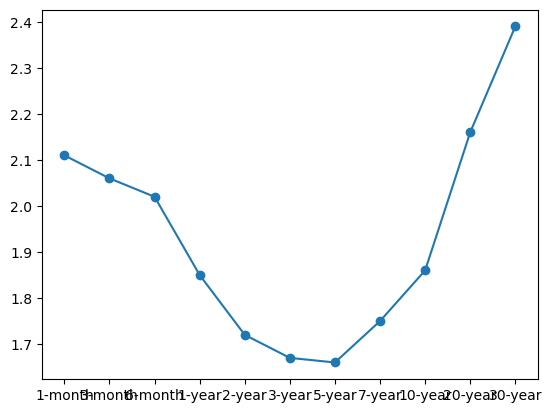

In [20]:
plt.plot(rates.iloc[-300,:],'o-')
plt.show()

## keep only records with all rates reported

In [21]:
zcount = [sum([1 for i,r in enumerate(rates.loc[d,:]) if np.isnan(r)]) for d in list(rates.index)]
keep = [i for i, c in enumerate(zcount) if c == 0]
good_rates = rates.iloc[keep, :]

print(good_rates.shape)
print(good_rates.index[0], 'to', good_rates.index[-1])

(4791, 11)
2001-07-31 to 2020-09-24


## compute correlation matrix and principal components analysis

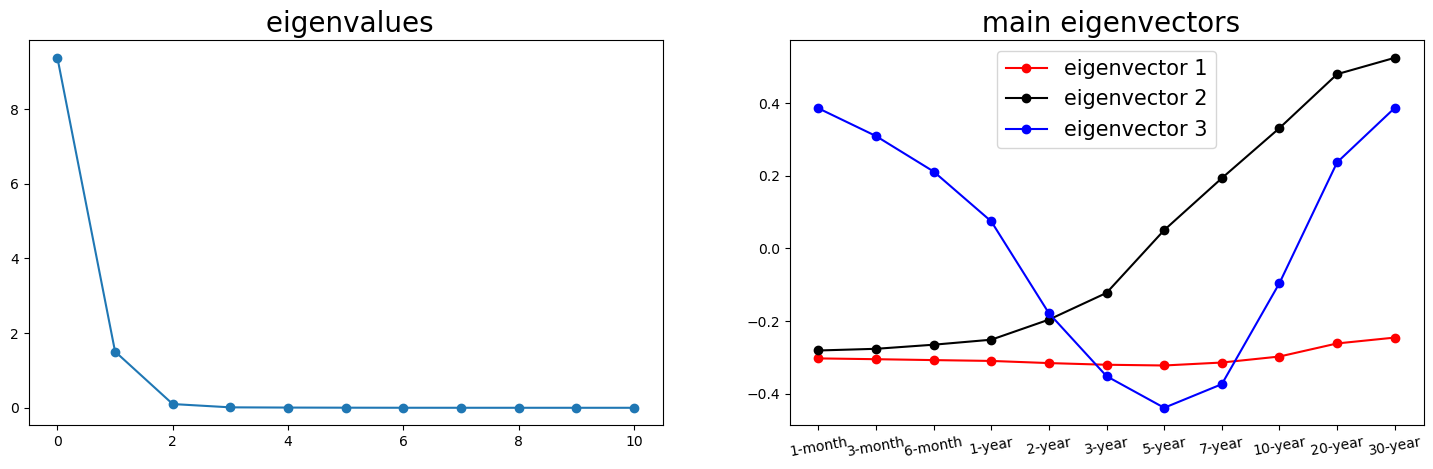

In [22]:
import matplotlib.pyplot as plt

def standardize_columns(x):
    """subtract mean and divide by standard deviation"""
    return (x - x.mean()) / x.std()

def plot_interest_rate_structure(evals, evecs, title=""):
    """plot eigenvalues and first 3 eigenvectors"""

    plt.figure(figsize=(18,5))
    plt.subplot(1,2,1)
    plt.plot(evals, 'o-')
    plt.title(f'{title} eigenvalues', fontsize=20)

    colors = ['red','black','blue']
    plt.subplot(1,2,2)
    for i, e in enumerate(evecs[:3]):
        plt.plot(e, 'o-', color=colors[i], label=f'eigenvector {i+1}')
        plt.xticks(range(11), x.columns, rotation=10)
    plt.legend(fontsize=15)
    plt.title(f'{title} main eigenvectors', fontsize=20)
    plt.plot()

start, end = '2006-01-01', '2020-08-28'
x = standardize_columns(good_rates[start:end])
cov = np.cov(x, rowvar = False)
evals, evecs = eigh(cov)
evecs = evecs.T
evals, evecs = np.flip(evals), np.flip(evecs, 0)

# print(evals)
# display(pd.DataFrame(evecs))

plot_interest_rate_structure(evals, evecs)

## validate the principal components analysis


### test that the eigenvalues and eigenvectors match

$$
\begin{bmatrix}
    e1  &  0  & 0      \\
    0   &  e2 & 0      \\
    0   &  0  & e3     
\end{bmatrix}
= 
\begin{bmatrix}
    v11  &  v21 &  v31      \\
    v12  &  v22 &  v32      \\
    v13  &  v23 &  v33      
\end{bmatrix} 
\begin{bmatrix}
    cov11  &  cov12 &  cov13      \\
    cov21  &  cov22 &  cov23      \\
    cov31  &  cov32 &  cov33      
\end{bmatrix} 
\begin{bmatrix}
    v11  &  v12 &  v13      \\
    v21  &  v22 &  v23      \\
    v31  &  v32 &  v33      
\end{bmatrix} $$

In [23]:
print(pd.DataFrame([evals, np.diag(evecs.dot(cov.dot(evecs.T)))], index=['eigenvalues','main diagonal']).round(4))

                   0       1       2       3       4       5      6       7   \
eigenvalues    9.3701  1.5059  0.1005  0.0121  0.0061  0.0029  0.001  0.0006   
main diagonal  9.3701  1.5059  0.1005  0.0121  0.0061  0.0029  0.001  0.0006   

                   8       9       10  
eigenvalues    0.0004  0.0002  0.0002  
main diagonal  0.0004  0.0002  0.0002  


### test that the eigenvectors are orthogonal to each other

$$
\begin{bmatrix}
    1   &  0  & 0      \\
    0   &  1  & 0      \\
    0   &  0  & 1     
\end{bmatrix}
= 
\begin{bmatrix}
    v11  &  v21 &  v31      \\
    v12  &  v22 &  v32      \\
    v13  &  v23 &  v33      
\end{bmatrix} 
\begin{bmatrix}
    v11  &  v12 &  v13      \\
    v21  &  v22 &  v23      \\
    v31  &  v32 &  v33      
\end{bmatrix} $$

In [24]:
print("\nfactors are orthogonal")
display(pd.DataFrame(evecs.dot(evecs.T)).round(5))


factors are orthogonal


,0,1,2,3,4,5,6,7,8,9,10
0,1.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0
1,0.0,1.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0
2,0.0,-0.0,1.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0
3,0.0,-0.0,-0.0,1.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0
4,-0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.0,0.0
5,-0.0,0.0,0.0,-0.0,0.0,1.0,-0.0,-0.0,0.0,0.0,0.0
6,0.0,-0.0,-0.0,0.0,0.0,-0.0,1.0,-0.0,-0.0,-0.0,-0.0
7,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,1.0,-0.0,-0.0,-0.0
8,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,1.0,-0.0,0.0
9,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,1.0,-0.0


## observe how the eigenstructure changes over time

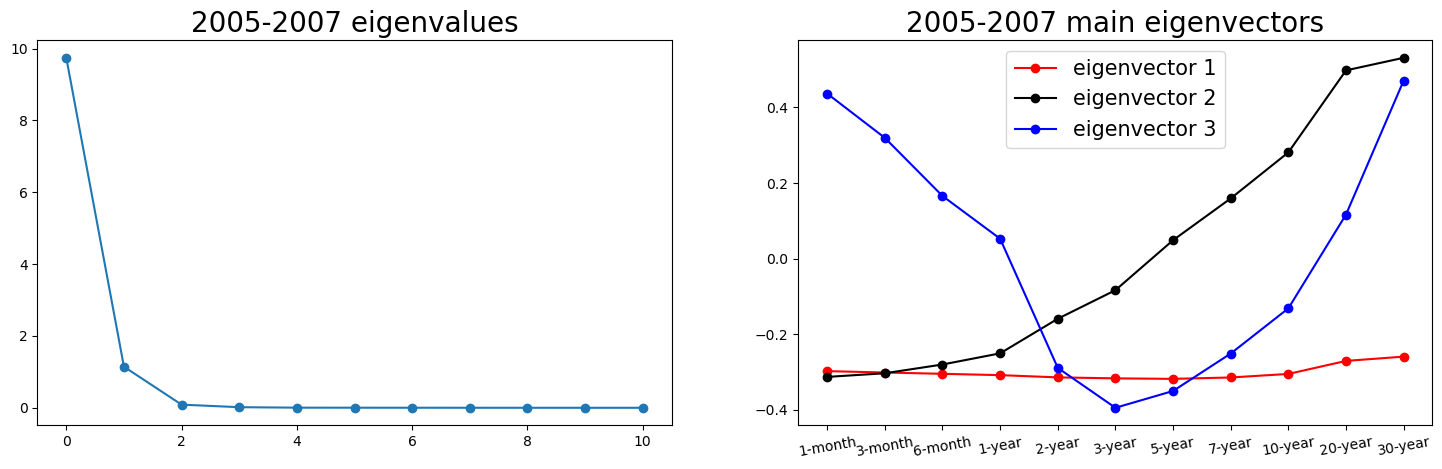

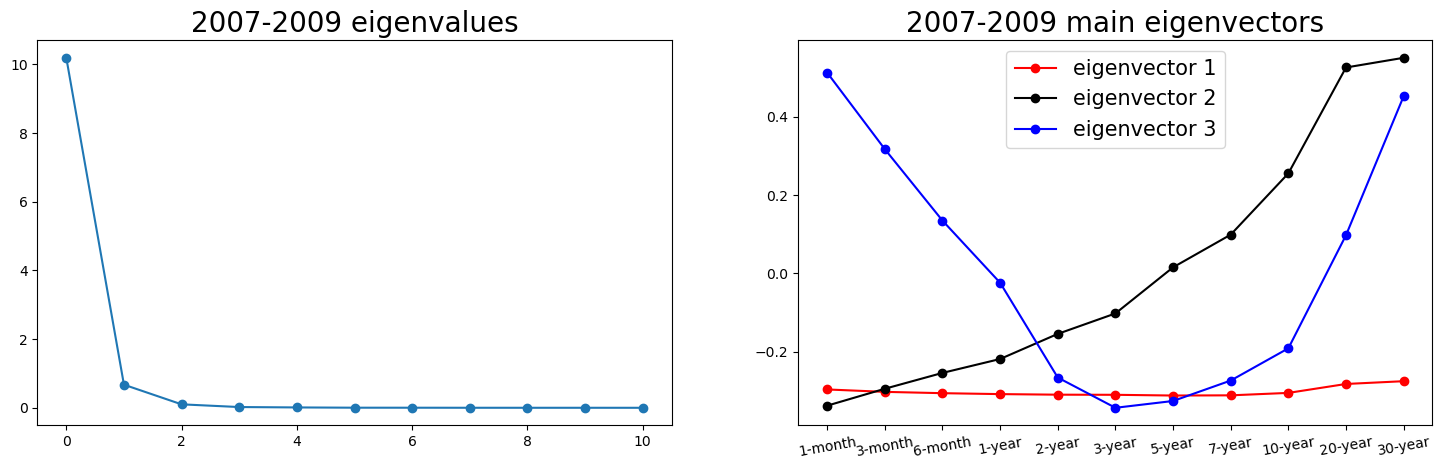

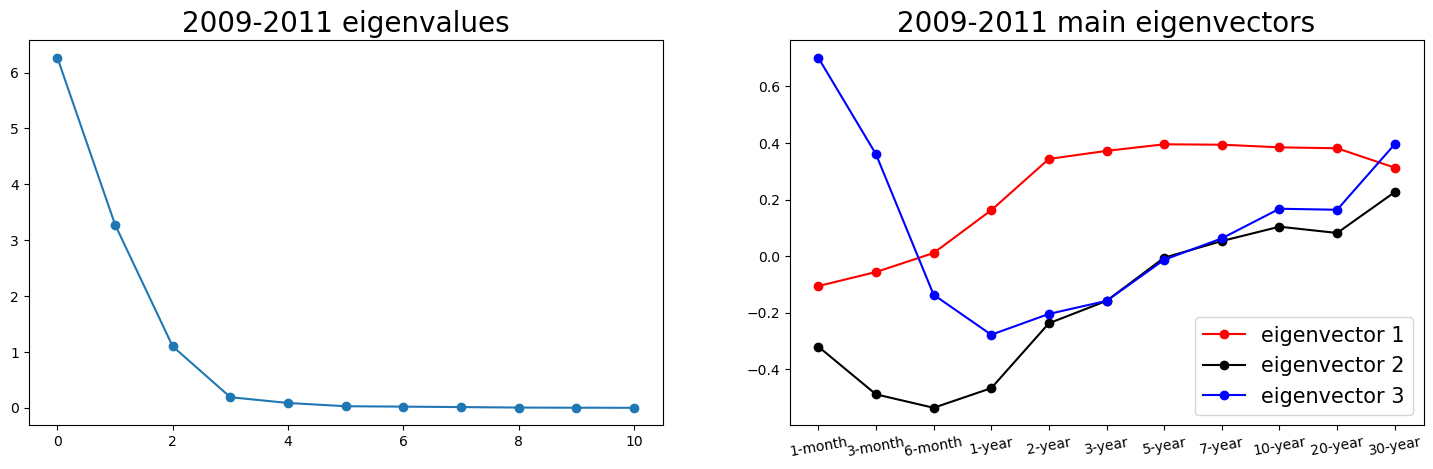

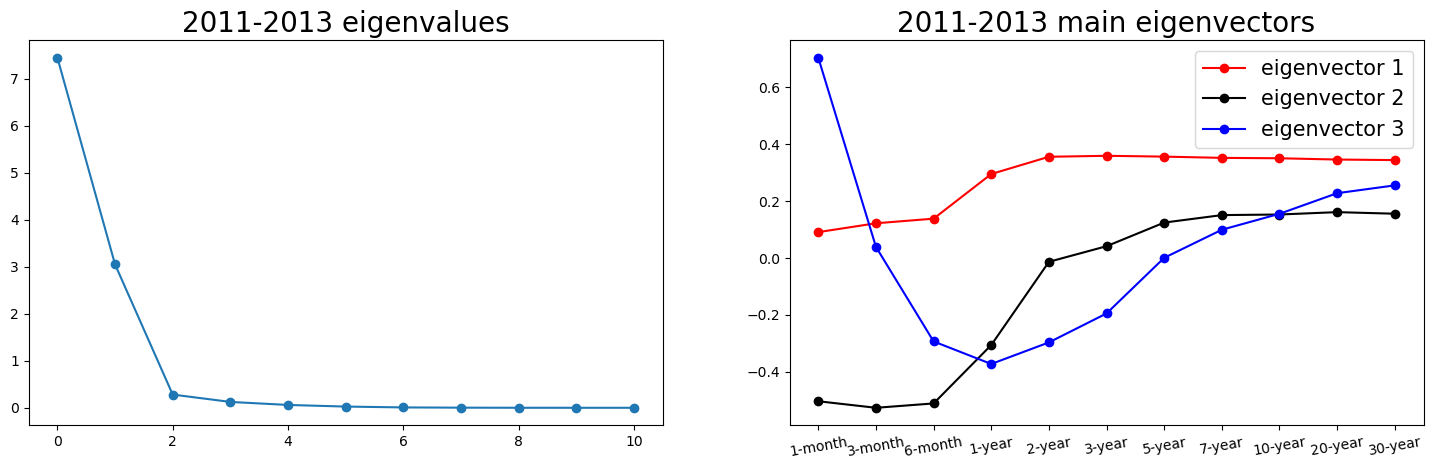

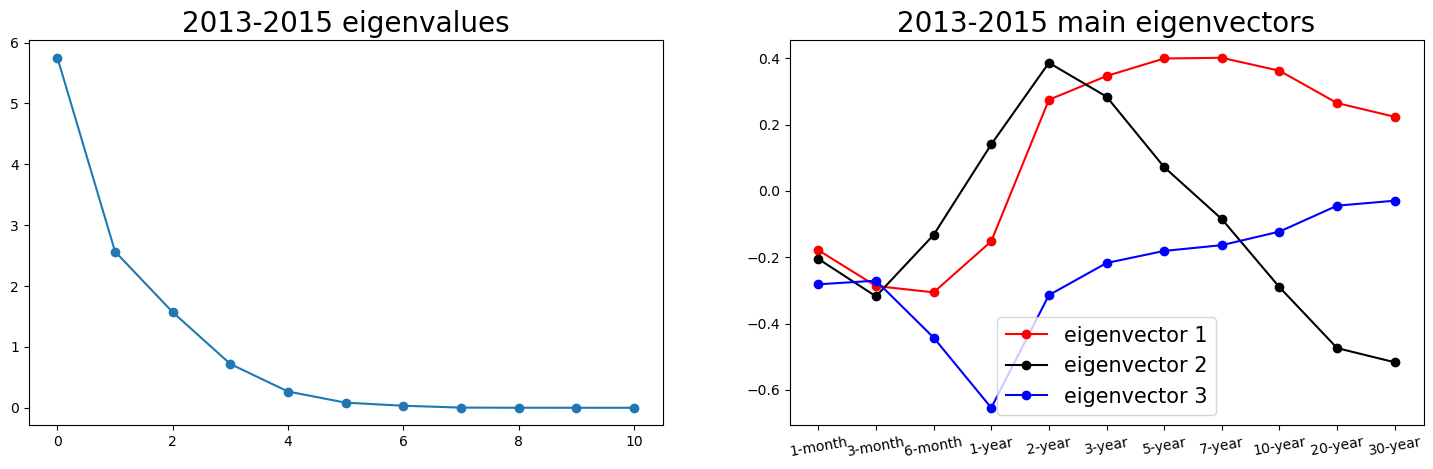

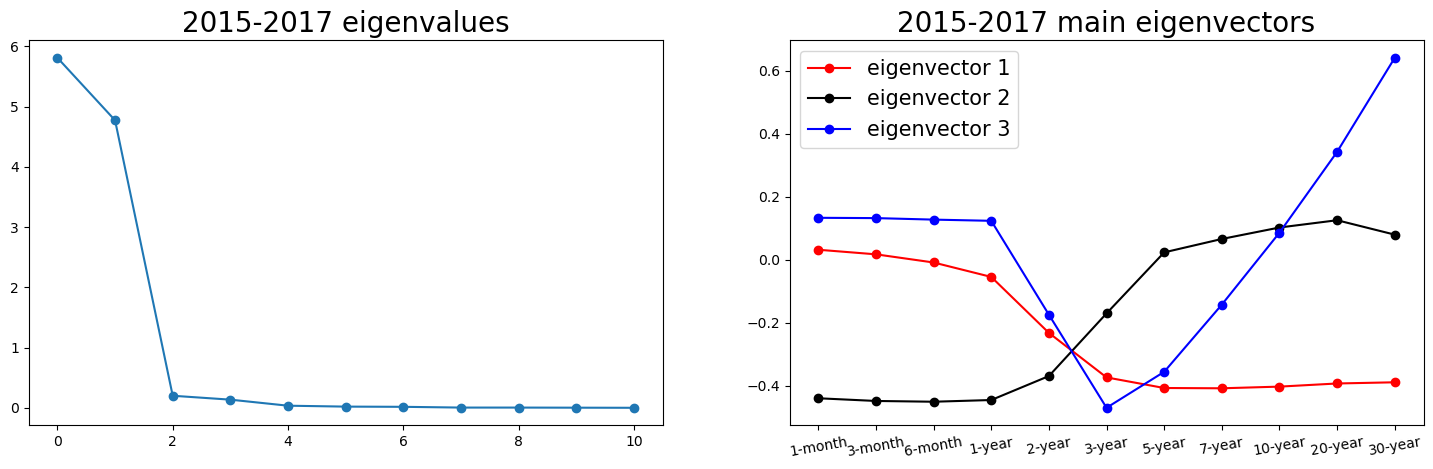

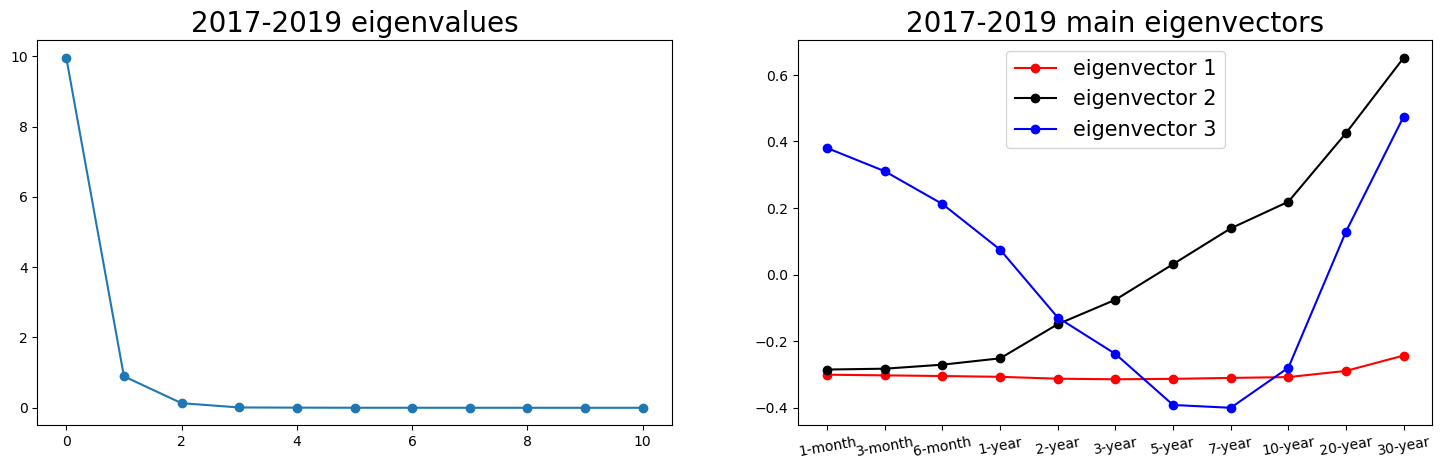

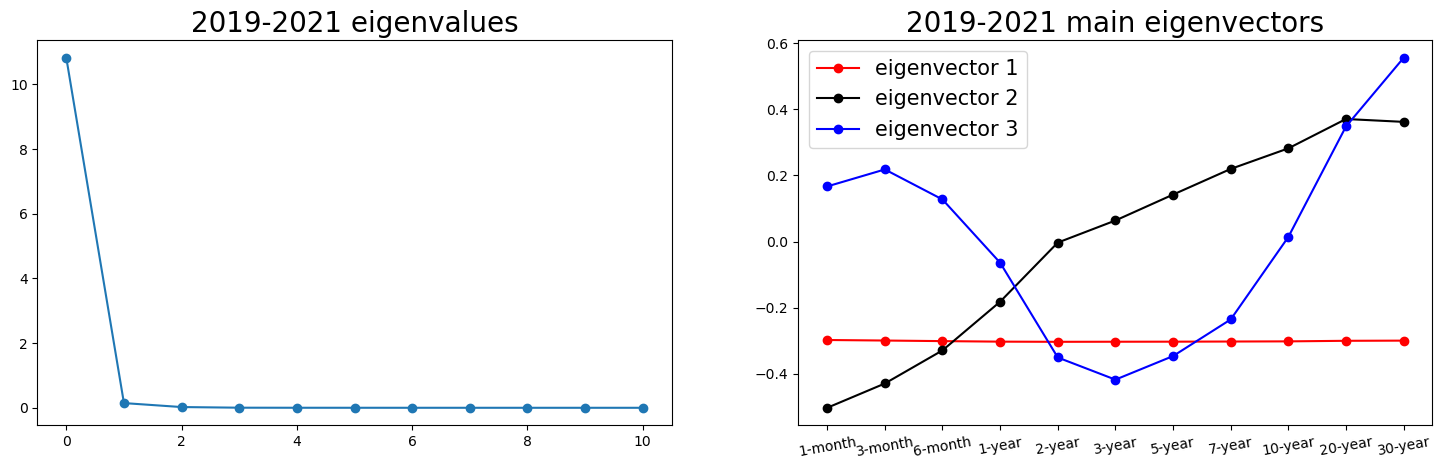

In [25]:
for year in np.arange(2005,2020,2):
    start, end = f'{year}-01-01', f'{year+2}-01-01'
    x = standardize_columns(good_rates[start:end])
    cov = np.cov(x, rowvar = False)
    evals, evecs = eigh(cov)
    evecs = evecs.T
    evals, evecs = np.flip(evals), np.flip(evecs, 0)
    plot_interest_rate_structure(evals, evecs, f'{start[:4]}-{end[:4]}')


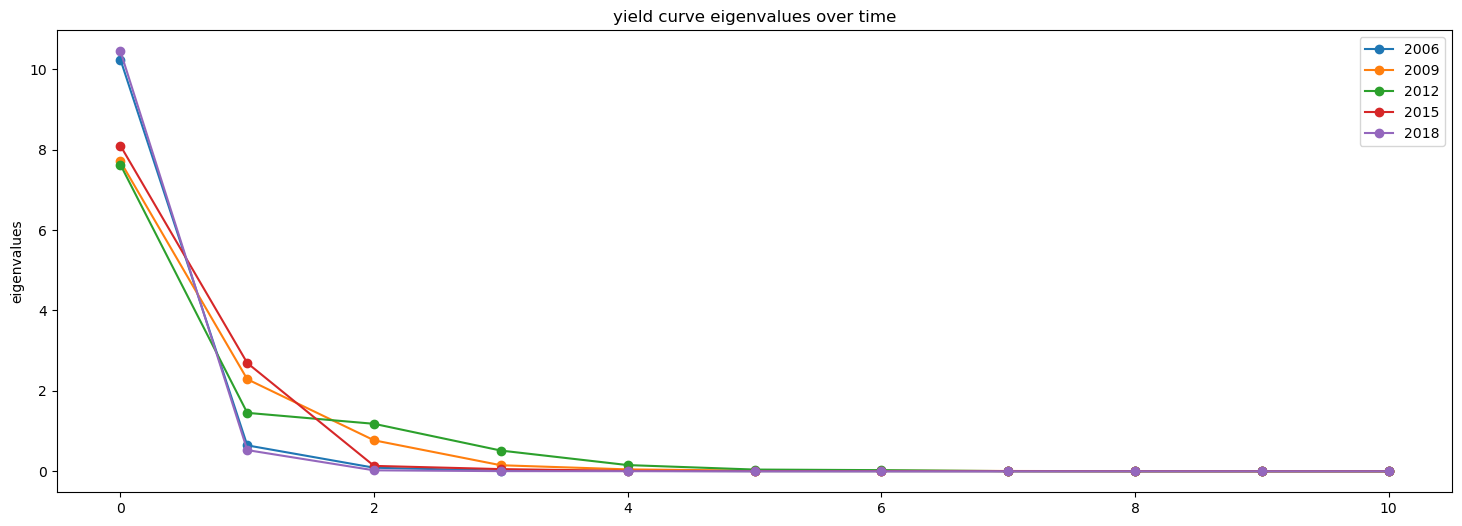

In [26]:
plt.figure(figsize=(18,6))
for year in np.arange(2006, 2019,3):
    start, end = f'{year}-01-01', f'{year+3}-01-01'
    x = standardize_columns(good_rates[start:end])
    cov = np.cov(x, rowvar = False)
    evals, evecs = eigh(cov)
    evecs = evecs.T
    evals, evecs = np.flip(evals), np.flip(evecs, 0)
    plt.plot(evals, 'o-', label=year)

plt.title("yield curve eigenvalues over time")
plt.ylabel("eigenvalues")
plt.legend()
plt.show()

# plotting the change in interest rates over time

[6.89170374 2.3686696  0.74099546 0.45930122 0.23149642 0.12291241
 0.08959991 0.04298614 0.02134672 0.01649713 0.01449126]


,0,1,2,3,4,5,6,7,8,9,10
0,-0.121088,-0.161131,-0.218004,-0.281661,-0.335987,-0.354272,-0.363496,-0.359706,-0.351386,-0.328599,-0.318044
1,0.451819,0.514252,0.453565,0.339375,0.045220,-0.025307,-0.121499,-0.174358,-0.212169,-0.242565,-0.242498
2,0.536161,0.239797,-0.123255,-0.301045,-0.411253,-0.305679,-0.113956,0.033483,0.165919,0.327318,0.371304
3,0.627983,-0.215392,-0.492389,-0.145708,0.309513,0.255671,0.157833,0.058093,-0.057465,-0.202321,-0.248754
4,0.289242,-0.720800,0.214573,0.483494,-0.077248,-0.148310,-0.166911,-0.126106,-0.033672,0.122523,0.170608
5,-0.121538,0.287711,-0.606148,0.497186,0.236697,-0.079436,-0.250331,-0.242440,-0.122965,0.144701,0.260776
6,0.030331,-0.057036,0.274059,-0.461002,0.578736,0.083412,-0.285151,-0.360232,-0.183796,0.150565,0.314284
7,0.003019,0.005958,-0.019664,0.004285,-0.471355,0.784425,-0.047757,-0.251641,-0.238783,0.036247,0.195238
8,-0.000983,-0.004166,0.009119,-0.004688,-0.013704,-0.230845,0.565413,0.101082,-0.643378,-0.182875,0.411232
9,-0.001164,0.006824,-0.002624,0.000290,-0.014543,-0.079142,0.419681,-0.415635,-0.135397,0.658739,-0.438538


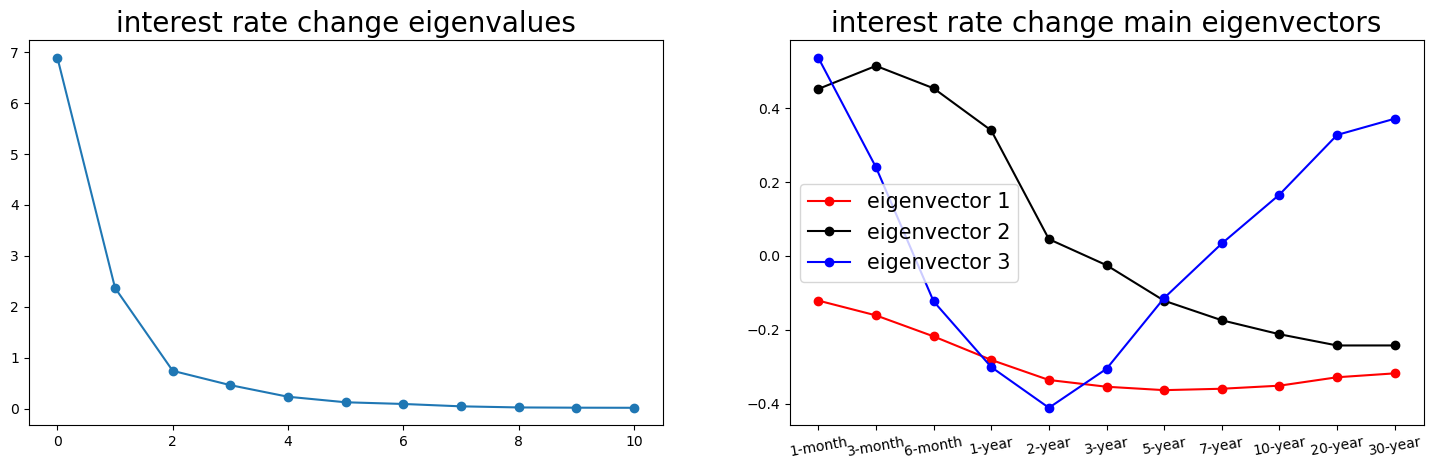

In [27]:
start, end = '2006-01-01', '2020-08-28'
rate_changes = good_rates.diff()[1:]

x1 = standardize_columns(rate_changes[start:end])
cov1 = np.cov(x1, rowvar = False)
evals1, evecs1 = eigh(cov1)
evecs1 = evecs1.T
evals1, evecs1 = np.flip(evals1), np.flip(evecs1, 0)

print(evals1)
display(pd.DataFrame(evecs1))

plot_interest_rate_structure(evals1, evecs1,"interest rate change")

# interest rate volatility

eigenvector column sums =  [1. 1. 1.]


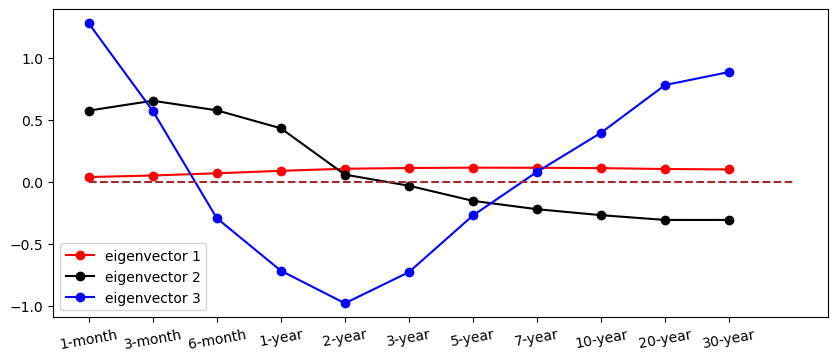

In [28]:
def standardize_column_sums(x):
    return (x.T / x.sum(axis=1)).T

evecs1_sum1 = standardize_column_sums(evecs1)
print('eigenvector column sums = ',evecs1_sum1[:3].sum(axis=1))

plt.figure(figsize=(10,4))
colors = ['red','black','blue']
for i, ev1 in enumerate(evecs1_sum1[:3]):
    plt.plot(ev1, 'o-', color=colors[i], label=f"eigenvector {i+1}")
plt.xticks(range(11), x.columns, rotation=10)
plt.plot([0,11],[0,0], '--', color='brown')
plt.legend(fontsize=10)      
plt.show()

# historical volatilities for factors and fixed maturities

In [29]:
pd.DataFrame(rate_changes.dot(evecs1_sum1[:3].T).std()).transpose()

,0,1,2
0,0.04457,0.094604,0.11297


In [30]:
pd.DataFrame(rate_changes.std()).transpose()

,1-month,3-month,6-month,1-year,2-year,3-year,5-year,7-year,10-year,20-year,30-year
0,0.062974,0.045996,0.03708,0.03769,0.050962,0.055317,0.059427,0.060175,0.057376,0.055133,0.053249


# Singular Value Decomposition - the history of the yield curve
## $X = UDV^T$

In [31]:
u,d,vh = np.linalg.svd(x)

print(f"input shape = {x.shape}")
print(u.shape, d.shape, vh.shape)

input shape = (684, 11)
(684, 684) (11,) (11, 11)


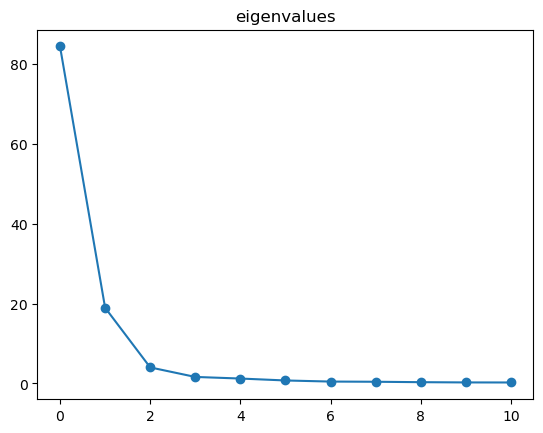

In [32]:
plt.plot(d, 'o-')
plt.title('eigenvalues')
plt.show()

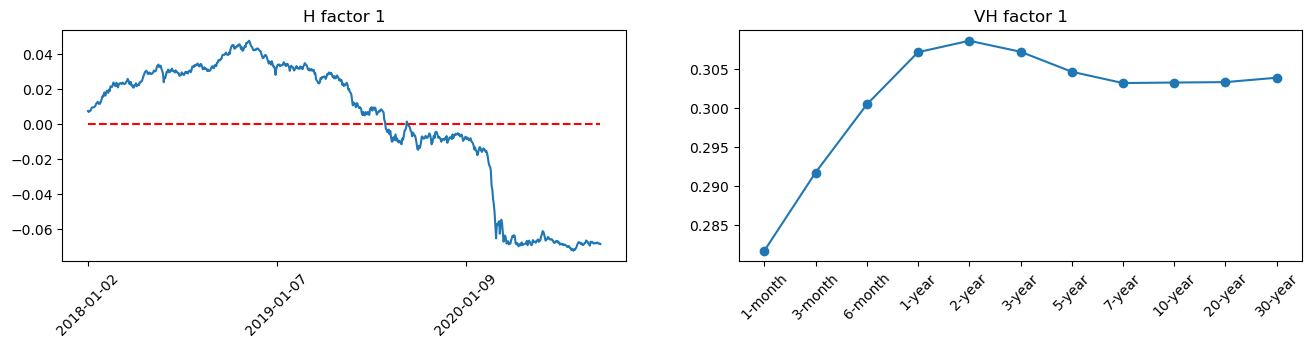

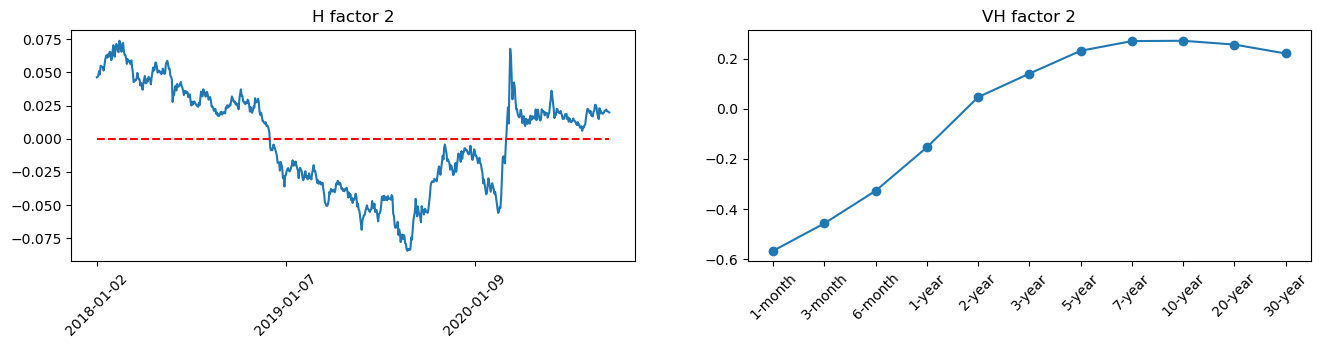

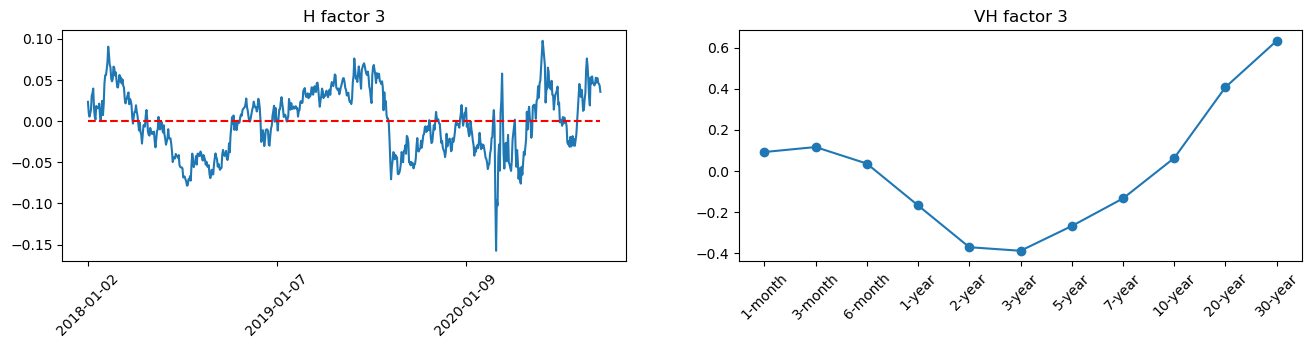

In [33]:
Ncomponents = 3

for i in range(Ncomponents):
    plt.figure(figsize=(16,3))
    
    plt.subplot(1,2,1)
    plt.plot(x.index, u.T[i], '-', label='W')
    plt.plot(x.index, [0] * len(x.index), '--', color='red')
    plt.title(f'H factor {i+1}')
    plt.xticks(x.index[::252],rotation=45)
    
    plt.subplot(1,2,2)
    plt.plot(x.columns, vh[i], 'o-', label='H')
    plt.title(f'VH factor {i+1}')
    plt.xticks(x.columns,rotation=45)
    plt.show()

# Non-negative matrix factorization

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html

## determine the number of interest rates components

NMF computes W and H to minimize $$||V-WH||_{F}$$
where the Frobenius norm is $$||A||_{F} = \sqrt{\sum_{j=1}^{m}\sum_{i=1}^{n}|a|_{ij}^2}$$

In [34]:
from sklearn.decomposition import NMF

start, end = '2006-01-01', '2020-02-11'
x = standardize_columns(good_rates[start:end])

def get_err(Ncomponents, x):
    model = NMF(n_components=Ncomponents, init='random', random_state=0)
    W = model.fit_transform(x)
    return model.reconstruction_err_

ncomp, err = np.array([(n, get_err(n, good_rates[start:end])) for n in range(1,10)]).T

plt.plot(ncomp, err, 'o-')
plt.title('NMF goodness of fit')
plt.xlabel('number of components')
plt.ylabel('Frobenius norm goodness-of-fit')
plt.show()

ModuleNotFoundError: No module named 'sklearn'

## plot the 3 factor NMF decomposition of interest rates

In [ ]:
Ncomponents = 3
model = NMF(n_components=Ncomponents, init='random', random_state=0)
W = pd.DataFrame(model.fit_transform(good_rates[start:end]))
H = pd.DataFrame(model.components_)
print(W.shape, H.shape)

In [ ]:
for i in range(Ncomponents):
    plt.figure(figsize=(16,3))
    
    plt.subplot(1,2,1)
    plt.plot(x.index, W.iloc[:,i], '-', label='W')
    plt.title(f'H factor {i+1}')
    plt.xticks(x.index[::252],rotation=45)
    
    plt.subplot(1,2,2)
    plt.plot(x.columns, H.iloc[i,:], 'o-', label='H')
    plt.title(f'W factor {i+1}')
    plt.xticks(x.columns,rotation=45)
    plt.legend()
    plt.show()